# Interest Rate Assets Pricing: Concepts and Practical Examples

This notebook explains how the most common interest rate instruments are priced. It is written for beginners — no prior experience with derivatives or quant finance is required.

## What is an interest rate asset?
An interest rate asset is any financial contract whose value depends on interest rates. Examples include:
- A **zero-coupon bond**: you lend money now and receive a lump sum later.
- A **fixed-coupon bond**: you receive regular interest payments plus your money back at the end.
- A **Forward Rate Agreement (FRA)**: a contract that locks in a future borrowing/lending rate today.
- An **interest rate swap**: an exchange of fixed payments for floating payments over time.

Banks, pension funds, insurance companies, and corporate treasuries all use these instruments to manage their exposure to changing interest rates.

## Why pricing matters
Every financial decision involving future cash flows has an interest rate embedded in it. Pricing these instruments correctly means answering: "What is the fair value today of money I will receive or pay in the future?"

## What you will learn
- The time value of money and how discount factors work
- How a yield curve is built and what it represents
- What an implied forward rate is and why it is useful
- How to price four core interest rate instruments
- How prices react when interest rates change (sensitivity analysis)

## Suggested reading path
1. Section 1: Start here to understand the fundamental building blocks.
2. The curve table and three charts: see how rates, discount factors, and forwards relate.
3. Section 2: Learn how each asset is priced step by step.
4. The pricing table: check the numbers for four worked examples.
5. Section 3: See how prices change when rates move.

## Modeling assumptions in this notebook
- Synthetic (illustrative) yield curve, not calibrated to live market data
- Annual compounding for coupon examples
- No credit risk, liquidity spreads, or collateral adjustments
- Single-curve framework for simplicity

In practice, trading desks use more sophisticated multi-curve setups and real bootstrapped yield curves.

In [7]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## 1. Core Concepts

### 1.1 The time value of money

**Key idea:** A dollar today is worth more than a dollar tomorrow.

Why? Because money you have today can be invested to earn interest. If you can invest at 3% per year, receiving $1,000 today is worth more than receiving $1,000 in five years.

Pricing any interest rate asset boils down to one question: **"What is every future cash flow worth in today's money?"**

Mathematically, the **present value** of a set of future cash flows is:

$$PV = \sum_{i} CF_i \cdot DF(0,t_i)$$

where:
- $CF_i$ = cash flow at time $t_i$
- $DF(0,t_i)$ = the **discount factor**: a number between 0 and 1 that tells you what one dollar at time $t_i$ is worth today

### 1.2 Zero rates and discount factors

A **zero rate** $r(t)$ is the interest rate for lending money from today to exactly time $t$, with no intermediate payments. It is the simplest building block of a yield curve.

Given a zero rate, the corresponding **discount factor** (using continuous compounding) is:

$$DF(0,t) = e^{-r(t)\,t}$$

**Real-world analogy:**
If the 5-year zero rate is 3.2%, then $DF(0,5) = e^{-0.032 \times 5} \approx 0.852$. This means $1 received in 5 years is worth about $0.85 today. Equivalently, to guarantee $1{,}000{,}000 in 5 years, you would invest about $852{,}000 today.

### 1.3 The yield curve

A **yield curve** (or **zero curve**) plots the zero rate against maturity. It is the foundation of all interest rate pricing.

Common shapes:
- **Normal (upward sloping)**: longer-term rates are higher than short-term rates. This is the usual shape because investors require extra return for locking up money longer.
- **Inverted**: short-term rates are higher, often signaling expected future rate cuts or a slowdown.
- **Flat**: rates are similar across all maturities.

### 1.4 Forward rates implied by discount factors

A **forward rate** $F(t_1, t_2)$ is the implied interest rate for a future lending period from $t_1$ to $t_2$. It is extracted from today's discount curve using no-arbitrage reasoning.

$$F(t_1,t_2) = \frac{DF(0,t_1)}{DF(0,t_2)}\frac{1}{t_2-t_1} - \frac{1}{t_2-t_1}$$

**Why no-arbitrage?** If the implied forward rate were inconsistent with the spot rates, investors could make a risk-free profit by combining two different strategies. The formula ensures no such opportunity exists.

> See the next section for a full beginner explanation of what "implied" means.

### 1.5 Asset classes covered in this notebook

| Asset | What it is | Why it is used |
|---|---|---|
| Zero-coupon bond | Pay price today, receive face value at maturity | Lock in a known return |
| Fixed-coupon bond | Periodic coupon payments + principal at maturity | Earn regular income |
| FRA | Agreement to pay/receive a fixed rate on a future loan | Hedge against rate moves |
| Interest rate swap | Exchange fixed payments for floating payments | Convert fixed exposure to floating or vice versa |

## 1b. What Is an Implied Forward Rate?

An **implied forward rate** is a future interest rate that is **inferred from today's yield curve** using no-arbitrage. It is one of the most important concepts in interest rate markets.

### What does "implied" mean?
The word *implied* means the rate is **not directly observable** in the market — it is **calculated** from other rates that are observable.

Think of it like this: you cannot buy a "1-year loan starting next year" directly from a bank today. But you *can* observe today's 1-year and 2-year zero rates. From those two numbers, you can calculate what the implied 1-year rate starting in 1 year must be, because otherwise arbitrage would be possible.

### Concrete intuition
Suppose:
- Today's 1-year zero rate: 3.0%
- Today's 2-year zero rate: 3.1%

You have two strategies that should produce the same result if markets are efficient:
1. Invest your money for 2 years at 3.1% directly.
2. Invest for 1 year at 3.0%, then at maturity reinvest the proceeds for another year at the implied forward rate $f_{1,2}$.

The implied forward rate $f_{1,2}$ is the break-even rate that makes strategy 1 and strategy 2 equivalent.

### Simple compounding formula

$$
(1+R_2)^2 = (1+R_1)(1+f_{1,2})
\quad \Rightarrow \quad
f_{1,2} = \frac{(1+R_2)^2}{1+R_1} - 1
$$

Using the numbers above: $f_{1,2} = \frac{(1.031)^2}{1.030} - 1 \approx 3.2\%$

### Why forward rates matter in practice
Forward rates are not just theoretical. They are the rates used to:
- **Price FRAs**: a Forward Rate Agreement pays/receives the difference between the implied forward and the agreed strike rate.
- **Price swaps**: the floating leg of a swap is priced by projecting cash flows using implied forward rates at each reset date.
- **Hedge future borrowing costs**: a treasurer who will need to borrow in 6 months can lock in today's implied forward rate now using an FRA.

### A note on forecasting
An implied forward rate is a **no-arbitrage pricing rate**, not necessarily a forecast. Realized future rates often differ from implied forwards because of risk premiums, central bank decisions, and macroeconomic surprises. Markets price the forward "as if" it will happen, but reality is much harder to predict.

---
**Coming up next:** the code cell below builds the yield curve table and computes all three quantities — zero rates, discount factors, and implied forward rates — for our synthetic curve.

In [8]:
curve_maturities = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30], dtype=float)
zero_rates = np.array([0.028, 0.029, 0.030, 0.031, 0.0315, 0.032, 0.033, 0.034, 0.035, 0.0355, 0.036], dtype=float)


def zero_rate(t: float) -> float:
    return float(np.interp(t, curve_maturities, zero_rates))


def discount_factor(t: float) -> float:
    return float(math.exp(-zero_rate(t) * t))


def forward_rate(t1: float, t2: float) -> float:
    tau = t2 - t1
    return float((discount_factor(t1) / discount_factor(t2) - 1.0) / tau)


curve_df = pd.DataFrame(
    {
        "maturity_years": curve_maturities,
        "zero_rate": [zero_rate(t) for t in curve_maturities],
        "discount_factor": [discount_factor(t) for t in curve_maturities],
    }
)
curve_df

,maturity_years,zero_rate,discount_factor
0,0.250000,0.028000,0.993024
1,0.500000,0.029000,0.985605
2,1.000000,0.030000,0.970446
3,2.000000,0.031000,0.939883
4,3.000000,0.031500,0.909828
5,5.000000,0.032000,0.852144
6,7.000000,0.033000,0.793739
7,10.000000,0.034000,0.711770
8,15.000000,0.035000,0.591555
9,20.000000,0.035500,0.491644


### How to read the curve table

The table above has one row for each maturity on our synthetic yield curve. Here is what each column means:

| Column | What it tells you |
|---|---|
| `maturity_years` | How far in the future the cash flow would occur |
| `zero_rate` | The annualised interest rate for a loan of exactly that length (no interim payments) |
| `discount_factor` | What $1 received at that maturity is worth today — always between 0 and 1, and always falling with time |

**Quick sanity check:** At maturity = 0.25 years (3 months), the discount factor should be very close to 1.0 because money in 3 months is almost as valuable as money today. At maturity = 30 years, the discount factor will be much smaller because you have to wait a long time.

**Upcoming charts:** The next cell visualises the same data as three separate graphs.


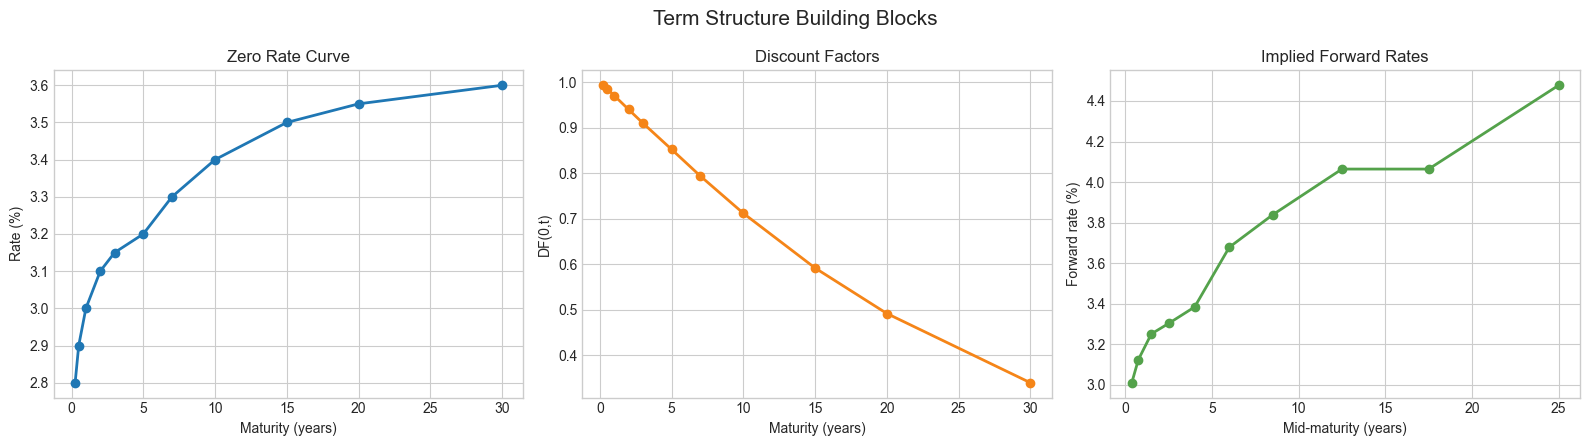

In [9]:
forward_nodes_t1 = curve_maturities[:-1]
forward_nodes_t2 = curve_maturities[1:]
forward_nodes_mid = 0.5 * (forward_nodes_t1 + forward_nodes_t2)
forward_nodes = np.array([forward_rate(t1, t2) for t1, t2 in zip(forward_nodes_t1, forward_nodes_t2)])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(curve_df["maturity_years"], 100 * curve_df["zero_rate"], marker="o", linewidth=2)
axes[0].set_title("Zero Rate Curve")
axes[0].set_xlabel("Maturity (years)")
axes[0].set_ylabel("Rate (%)")

axes[1].plot(curve_df["maturity_years"], curve_df["discount_factor"], marker="o", linewidth=2, color="#F58518")
axes[1].set_title("Discount Factors")
axes[1].set_xlabel("Maturity (years)")
axes[1].set_ylabel("DF(0,t)")

axes[2].plot(forward_nodes_mid, 100 * forward_nodes, marker="o", linewidth=2, color="#54A24B")
axes[2].set_title("Implied Forward Rates")
axes[2].set_xlabel("Mid-maturity (years)")
axes[2].set_ylabel("Forward rate (%)")

fig.suptitle("Term Structure Building Blocks", fontsize=15)
fig.tight_layout()
plt.show()

### How to read the term structure charts

Three panels, each showing a different view of the same curve:

**Left — Zero Rate Curve**
- The x-axis is maturity in years; the y-axis is the rate in percent.
- Each point is the zero rate for a loan of exactly that length.
- In a normal yield environment, this line slopes upward: longer loans carry higher rates.
- If you see a flat or inverted curve, it often signals market expectations of future rate cuts.

**Middle — Discount Factors**
- This is the "translation table" from future money to today's money.
- The line always starts near 1.0 (short maturities) and falls towards 0 for very long maturities.
- A steeper drop means higher rates are discounting future cash flows more aggressively.
- **Key insight:** the lower the discount factor at a given maturity, the cheaper it is to sell a promise of $1 at that date — and the cheaper it is to fund long-dated liabilities.

**Right — Implied Forward Rates**
- Each point is the implied rate for the *next segment* of the curve (e.g., the rate from year 5 to year 7).
- Forward rates are higher than zero rates when the curve is upward sloping, because the curve must be consistent with implied reinvestment rates.
- FRA and swap floating leg pricing is driven by these values.


## 2. Pricing Interest Rate Assets

Now that we have the curve, we can price any instrument by discounting its cash flows. Below is a step-by-step explanation of how each asset is priced.

---

### 2.1 Zero-Coupon Bond (ZCB)

**What is it?** You pay a price today and receive a single lump-sum payment (the *face value*) at maturity. There are no coupon payments in between. A US Treasury bill is a common example.

**How is it priced?** Simply discount the face value back to today:

$$P_{ZCB} = F \cdot DF(0,T)$$

- $F$ = face value (e.g., $5{,}000{,}000)
- $T$ = maturity in years
- $DF(0,T)$ = discount factor from the yield curve

**Intuition:** If the 5-year discount factor is 0.852, you would pay $4{,}260{,}000 today to receive $5{,}000{,}000 in five years.

---

### 2.2 Fixed-Coupon Bond

**What is it?** A loan where you receive regular coupon payments (a percentage of the face value) every year, plus the full face value at maturity. Government bonds and corporate bonds work this way.

**How is it priced?** Each coupon is a separate cash flow — discount them all individually, then add the discounted face value:

$$P_{bond} = \sum_{i=1}^{n} C_i \cdot DF(0,t_i) + F \cdot DF(0,T)$$

- $C_i = F \times \text{coupon rate}$ = coupon paid at time $t_i$
- The last term is the discounted return of principal

**Intuition:** A 7-year bond with a 4.2% coupon on a $3M face pays $126,000 per year for 7 years, plus $3,000,000 at year 7. Price each payment using the discount factor for its specific maturity, then sum them all up.

**Macaulay Duration:** We also calculate duration, which measures how many years, on average, it takes to receive all the bond's cash flows (weighted by present value). A higher duration means the bond is more sensitive to interest rate changes.

---

### 2.3 Forward Rate Agreement (FRA)

**What is it?** A contract where two parties agree today on an interest rate that will apply to a future loan. For example: "we agree now that you will borrow at 3.6% for the 6-month period starting one year from today."

**Why use it?** A company that knows it will need to borrow money in 12 months can use an FRA to lock in the rate today, removing uncertainty about future borrowing costs.

**How is it priced?** The value of the FRA is the difference between the implied forward rate and the agreed strike rate, discounted back to today:

$$V_{FRA} = N \cdot DF(0,T_2) \cdot (F(T_1,T_2) - K) \cdot (T_2-T_1)$$

- $N$ = notional (the hypothetical loan amount)
- $F(T_1,T_2)$ = implied forward rate from the curve for the period $[T_1, T_2]$
- $K$ = the agreed (strike) rate in the contract
- $T_2 - T_1$ = length of the accrual period in years

**Intuition:** If the implied forward rate is higher than the strike, the FRA buyer (who pays fixed / receives floating) profits. If the implied forward is lower, the buyer loses.

---

### 2.4 Plain-Vanilla Interest Rate Swap

**What is it?** Two parties exchange cash flows over several years. One party pays a *fixed rate* (agreed upfront); the other pays a *floating rate* (which resets at each payment date based on market rates). No principal is exchanged.

**Why use it?**
- A company with a floating-rate loan can enter a swap to convert those payments to fixed — giving certainty about future interest costs.
- An investor holding fixed-rate bonds can swap them to floating to benefit from rising rates.

**How is it priced?**
- **Fixed leg PV** — the series of fixed payments, discounted: $\;N \cdot K \cdot \sum_i \alpha_i DF(0,t_i)$
- **Floating leg PV** — under the single-curve simplification, it equals: $\;N \cdot (1 - DF(0,T_n))$
- **Payer-fixed NPV** = Floating leg PV − Fixed leg PV

**Par rate:** The par rate is the fixed rate that makes the swap worth exactly zero at inception (floating leg PV = fixed leg PV). When the fixed rate exceeds the par rate, a payer-fixed swap has negative NPV (you are overpaying on the fixed side).

**Intuition:** Think of the floating leg as a series of deposits. Under the no-arbitrage principle, its value simplifies neatly to $N(1-DF(0,T_n))$ — the cost of recreating all floating payments by rolling one-period investments from today to maturity.

In [4]:
def zcb_price(face_value: float, maturity: float) -> float:
    return float(face_value * discount_factor(maturity))


def fixed_bond_price(face_value: float, coupon_rate: float, maturity: int) -> float:
    payment_times = np.arange(1, maturity + 1, dtype=float)
    coupon = face_value * coupon_rate
    pv_coupons = sum(coupon * discount_factor(t) for t in payment_times)
    pv_principal = face_value * discount_factor(maturity)
    return float(pv_coupons + pv_principal)


def fixed_bond_macaulay_duration(face_value: float, coupon_rate: float, maturity: int) -> float:
    payment_times = np.arange(1, maturity + 1, dtype=float)
    coupon = face_value * coupon_rate
    cashflows = np.full_like(payment_times, coupon, dtype=float)
    cashflows[-1] += face_value
    pvs = np.array([cf * discount_factor(t) for cf, t in zip(cashflows, payment_times)])
    return float(np.sum(payment_times * pvs) / np.sum(pvs))


def fra_value(notional: float, t1: float, t2: float, strike: float) -> float:
    fwd = forward_rate(t1, t2)
    tau = t2 - t1
    return float(notional * discount_factor(t2) * (fwd - strike) * tau)


def swap_schedule(maturity: int) -> np.ndarray:
    return np.arange(1, maturity + 1, dtype=float)


def swap_par_rate(maturity: int) -> float:
    pay_times = swap_schedule(maturity)
    accruals = np.diff(np.concatenate(([0.0], pay_times)))
    dfs = np.array([discount_factor(t) for t in pay_times])
    annuity = float(np.sum(accruals * dfs))
    return float((1.0 - dfs[-1]) / annuity)


def payer_swap_npv(notional: float, maturity: int, fixed_rate: float) -> float:
    pay_times = swap_schedule(maturity)
    accruals = np.diff(np.concatenate(([0.0], pay_times)))
    dfs = np.array([discount_factor(t) for t in pay_times])
    annuity = float(np.sum(accruals * dfs))

    fixed_leg = notional * fixed_rate * annuity
    floating_leg = notional * (1.0 - dfs[-1])
    return float(floating_leg - fixed_leg)

In [5]:
asset_rows = []

zcb_face = 5_000_000
zcb_maturity = 5.0
zcb_pv = zcb_price(zcb_face, zcb_maturity)
asset_rows.append(
    {
        "asset": "5Y Zero Coupon Bond",
        "key_parameter": f"Face={zcb_face:,.0f}",
        "metric": "Price",
        "value": zcb_pv,
    }
)

bond_face = 3_000_000
bond_coupon = 0.042
bond_maturity = 7
bond_pv = fixed_bond_price(bond_face, bond_coupon, bond_maturity)
bond_duration = fixed_bond_macaulay_duration(bond_face, bond_coupon, bond_maturity)
asset_rows.extend(
    [
        {
            "asset": "7Y Fixed Coupon Bond",
            "key_parameter": f"Coupon={100*bond_coupon:.2f}%",
            "metric": "Price",
            "value": bond_pv,
        },
        {
            "asset": "7Y Fixed Coupon Bond",
            "key_parameter": f"Coupon={100*bond_coupon:.2f}%",
            "metric": "Macaulay Duration (years)",
            "value": bond_duration,
        },
    ]
)

fra_notional = 10_000_000
fra_t1, fra_t2 = 1.0, 1.5
fra_strike = 0.036
fra_npv = fra_value(fra_notional, fra_t1, fra_t2, fra_strike)
asset_rows.append(
    {
        "asset": "1Yx1.5Y FRA",
        "key_parameter": f"Strike={100*fra_strike:.2f}%",
        "metric": "NPV",
        "value": fra_npv,
    }
)

swap_notional = 20_000_000
swap_maturity = 5
par_rate_5y = swap_par_rate(swap_maturity)
quoted_fixed_rate = par_rate_5y + 0.0025
swap_npv = payer_swap_npv(swap_notional, swap_maturity, quoted_fixed_rate)
asset_rows.extend(
    [
        {
            "asset": "5Y Interest Rate Swap",
            "key_parameter": "Par fixed rate",
            "metric": "Par Rate (%)",
            "value": 100 * par_rate_5y,
        },
        {
            "asset": "5Y Interest Rate Swap",
            "key_parameter": f"Fixed={100*quoted_fixed_rate:.2f}%",
            "metric": "Payer Swap NPV",
            "value": swap_npv,
        },
    ]
)

asset_pricing_df = pd.DataFrame(asset_rows)
asset_pricing_df

,asset,key_parameter,metric,value
0,5Y Zero Coupon Bond,"Face=5,000,000",Price,"4,260,718.944831"
1,7Y Fixed Coupon Bond,Coupon=4.20%,Price,"3,158,588.973424"
2,7Y Fixed Coupon Bond,Coupon=4.20%,Macaulay Duration (years),6.228874
3,1Yx1.5Y FRA,Strike=3.60%,NPV,"-20,302.725258"
4,5Y Interest Rate Swap,Par fixed rate,Par Rate (%),3.247422
5,5Y Interest Rate Swap,Fixed=3.50%,Payer Swap NPV,"-227,651.680826"


### How to read the pricing table

The table above shows four worked examples. Here is how to interpret each row:

| Asset | What the metric tells you |
|---|---|
| **5Y Zero Coupon Bond** — Price | What you would pay today for the right to receive $5,000,000 in 5 years. It will be less than $5M due to discounting. |
| **7Y Fixed Coupon Bond** — Price | The fair value of receiving 4.2% annual coupons on $3M for 7 years, plus $3M at the end. Could be above or below $3M depending on whether the coupon is above/below market rates. |
| **7Y Fixed Coupon Bond** — Macaulay Duration | Roughly, the "weighted average time to receive cash flows". A duration of ~6 means the bond behaves similarly to a 6-year zero-coupon bond in terms of rate sensitivity. |
| **1Yx1.5Y FRA** — NPV | The current profit/loss of the FRA contract. A positive value means the forward rate is above the agreed strike (3.6%), so the buyer gains. Negative = forward is below strike. |
| **5Y Swap** — Par Rate | The fixed rate that makes the swap worth zero at inception. Compare this to the actual rate to understand at-market vs off-market pricing. |
| **5Y Swap** — Payer Swap NPV | The current value to the party paying fixed. Negative means the fixed rate (above par) is expensive relative to the curve — they are paying more than the fair rate. |

**General rule:** If the fixed or coupon rate on an instrument is *above* the market rate implied by the curve, the instrument trades at a discount (below par). If it is *below* the market rate, it trades at a premium (above par).


## 3. Sensitivity Analysis: How Prices React to Rate Changes

No matter how carefully you price an instrument today, interest rates will move tomorrow. **Sensitivity analysis** asks: "If rates move up or down, how much does the value of my position change?"

This is one of the most practical skills in fixed income — traders and risk managers do this every day.

### What is a basis point (bp)?
A **basis point** is one-hundredth of one percent:

$$1\text{ bp} = 0.01\% = 0.0001$$

So a move from 3.0% to 3.1% is a **10 bp** move. A move from 3.0% to 4.0% is a **100 bp** move.

Basis points are the standard unit for quoting rate changes in fixed income markets.

### What is a parallel shock?
A **parallel shock** moves every point on the yield curve up or down by the same amount. For example, a +100 bp shock adds 1% to every maturity simultaneously. This is a simplified but very useful starting point for risk analysis.

In reality, yield curves twist and change shape as well, but parallel shifts capture the dominant source of risk for most fixed income positions.

### What to expect for each asset

| Asset | When rates rise | When rates fall |
|---|---|---|
| Zero-coupon bond | Price falls (higher discount rate → lower PV of the future lump sum) | Price rises |
| Fixed-coupon bond | Price falls (same reason; more payments → more cumulative discounting impact) | Price rises |
| Payer swap (pay fixed, receive floating) | NPV rises (floating leg resets to higher rates → you receive more) | NPV falls |

This explains the **opposite convexity** of swaps vs bonds: if you hold a fixed-rate bond and a payer swap, the two positions partially offset each other.

### About the charts below
The next cell runs the same pricing functions across a range of shocks from −200 bp to +200 bp. The three charts show the price or NPV path for each asset as rates move. Look for:
- **Curvature**: bonds and ZCBs show convexity (the curve bends, not just a straight line)
- **Slope**: the direction confirms whether the asset has positive or negative rate sensitivity
- **Zero crossing** (swap chart): the horizontal black line shows where the swap transitions from in-the-money to out-of-the-money


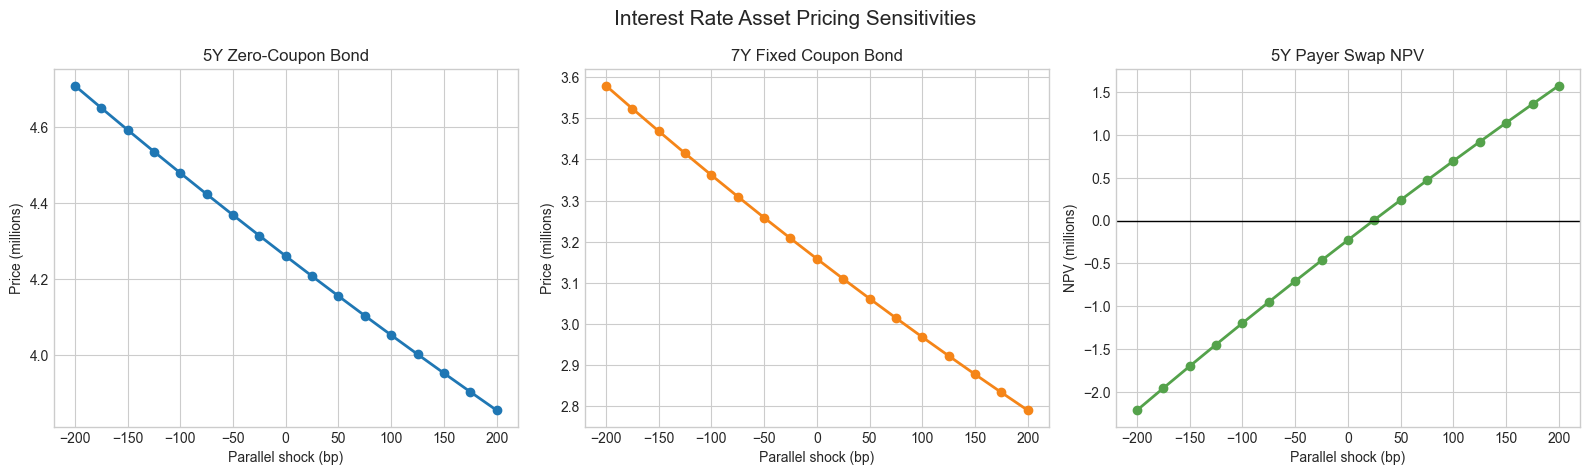

,shock_bp,zcb_price,bond_price,payer_swap_npv
0,-200,"4,708,822.667921","3,579,598.066346","-2,213,961.351518"
1,-175,"4,650,328.733301","3,523,839.603008","-1,954,970.861715"
2,-150,"4,592,561.422007","3,469,006.827751","-1,699,113.657627"
3,-125,"4,535,511.707779","3,415,084.040490","-1,446,351.336449"
4,-100,"4,479,170.676483","3,362,055.809837","-1,196,645.968670"


In [6]:
def discount_factor_shocked(t: float, shock: float) -> float:
    return float(math.exp(-(zero_rate(t) + shock) * t))


def zcb_price_shocked(face_value: float, maturity: float, shock: float) -> float:
    return float(face_value * discount_factor_shocked(maturity, shock))


def fixed_bond_price_shocked(face_value: float, coupon_rate: float, maturity: int, shock: float) -> float:
    payment_times = np.arange(1, maturity + 1, dtype=float)
    coupon = face_value * coupon_rate
    pv_coupons = sum(coupon * discount_factor_shocked(t, shock) for t in payment_times)
    pv_principal = face_value * discount_factor_shocked(maturity, shock)
    return float(pv_coupons + pv_principal)


def payer_swap_npv_shocked(notional: float, maturity: int, fixed_rate: float, shock: float) -> float:
    pay_times = swap_schedule(maturity)
    accruals = np.diff(np.concatenate(([0.0], pay_times)))
    dfs = np.array([discount_factor_shocked(t, shock) for t in pay_times])
    annuity = float(np.sum(accruals * dfs))
    fixed_leg = notional * fixed_rate * annuity
    floating_leg = notional * (1.0 - dfs[-1])
    return float(floating_leg - fixed_leg)


shock_bp_grid = np.arange(-200, 225, 25)
shock_rows = []
for shock_bp in shock_bp_grid:
    shock = shock_bp / 10_000
    shock_rows.append(
        {
            "shock_bp": shock_bp,
            "zcb_price": zcb_price_shocked(zcb_face, zcb_maturity, shock),
            "bond_price": fixed_bond_price_shocked(bond_face, bond_coupon, bond_maturity, shock),
            "payer_swap_npv": payer_swap_npv_shocked(swap_notional, swap_maturity, quoted_fixed_rate, shock),
        }
    )

shock_df = pd.DataFrame(shock_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
axes[0].plot(shock_df["shock_bp"], shock_df["zcb_price"] / 1e6, marker="o", linewidth=2)
axes[0].set_title("5Y Zero-Coupon Bond")
axes[0].set_xlabel("Parallel shock (bp)")
axes[0].set_ylabel("Price (millions)")

axes[1].plot(shock_df["shock_bp"], shock_df["bond_price"] / 1e6, marker="o", linewidth=2, color="#F58518")
axes[1].set_title("7Y Fixed Coupon Bond")
axes[1].set_xlabel("Parallel shock (bp)")
axes[1].set_ylabel("Price (millions)")

axes[2].plot(shock_df["shock_bp"], shock_df["payer_swap_npv"] / 1e6, marker="o", linewidth=2, color="#54A24B")
axes[2].axhline(0.0, color="black", linewidth=1)
axes[2].set_title("5Y Payer Swap NPV")
axes[2].set_xlabel("Parallel shock (bp)")
axes[2].set_ylabel("NPV (millions)")

fig.suptitle("Interest Rate Asset Pricing Sensitivities", fontsize=15)
fig.tight_layout()
plt.show()

shock_df.head()

### How to read the sensitivity charts

**Left — 5Y Zero-Coupon Bond Price**
- x-axis: rate shock in basis points (negative = rates fell, positive = rates rose)
- y-axis: bond price in millions
- The line slopes **downward**: higher rates → lower price. This is the core bond rule.
- Notice the slight upward **curvature** (convexity): the price falls faster when rates rise than it gains when rates fall by the same amount.

**Middle — 7Y Fixed Coupon Bond Price**
- Same downward slope as the ZCB.
- The curvature is slightly more pronounced because there are many cash flows across different maturities — each one is discounted differently, producing more convexity.
- The price at the 0 bp shock is your base price from the pricing table above.

**Right — 5Y Payer Swap NPV**
- x-axis: rate shock in basis points
- y-axis: NPV in millions (can be positive or negative)
- The line slopes **upward**: when rates rise, the floating leg you receive becomes more valuable, so the payer swap gains.
- The **black horizontal line** at zero marks the break-even level. Where the NPV line crosses zero is roughly the par rate for this swap.
- The base NPV is negative because we priced this swap with a fixed rate 25 bp *above* the par rate — you are overpaying on the fixed side.

**Key takeaway:** Bonds and swaps have opposite sensitivity to rates. This is why swaps are routinely used to **hedge** bond portfolios — if rates rise and bond prices fall, payer swap gains offset some of that loss.


## 4. Implied Maturity from an Observed Price

So far we have been pricing **forward**: given a maturity, compute the fair price. This section reverses the problem — given a **price you observe in the market**, what **time to maturity** does the current yield curve imply?

This is called the **inverse pricing problem**, and it turns up in several practical situations:

| Use case | What you know | What you want to find |
|---|---|---|
| Stripping | Market price of a zero-coupon Treasury strip | Which maturity point on the curve it sits at |
| Curve fitting | A set of observed bond prices | A smooth curve that is consistent with all of them |
| Relative value | A bond's quoted price | Whether its implied maturity is shorter or longer than its stated maturity (flag for mispricing) |
| Duration targeting | A target portfolio duration | Which maturity bond achieves that duration at the current price |

---

### How the inversion works

#### Zero-Coupon Bond (clean, continuous)

For a ZCB, the price formula is:

$$P = F \cdot e^{-r(T) \cdot T}$$

Rearranging gives:

$$r(T) \cdot T = -\ln\!\left(\frac{P}{F}\right)$$

The right-hand side is known once you observe the price. The left-hand side still depends on $T$ through $r(T)$ — the zero rate at maturity $T$ on the curve (which changes with maturity). So **you cannot solve for $T$ analytically**; instead, you use a numerical root-finder (`scipy.optimize.brentq`): find $T$ such that $F \cdot DF(0,T) - P = 0$.

Because the ZCB price **monotonically decreases** as maturity grows (longer wait → heavier discounting), the solution is always **unique**.

#### Fixed-Coupon Bond (discrete maturities)

A coupon bond pays coupons at integer years. Prices are not a smooth function of $T$ — changing maturity by one year changes the entire coupon schedule. So the approach is:

1. Compute the fair price at every integer maturity from 1 to 30 years.
2. Find the two adjacent integer years that **bracket** your target price.
3. **Linearly interpolate** between them to estimate the fractional maturity.

> **Important:** For a premium bond (coupon rate > market yield), price *increases* with maturity. For a discount bond (coupon < yield), price *decreases* with maturity. Either way, the price-maturity relationship is monotonic, so inversion is well-defined. A par bond (coupon = yield) always prices at face value — maturity cannot be inferred from price alone.

---

### What the code below does

1. Tests six different ZCB prices (all below face value of $5M) and solves for the implied maturity of each.
2. Tests five target prices for a 4.2% coupon bond and interpolates the implied maturity.
3. Shows both results as tables, with a `check_price` column to confirm the inversion is correct.
4. Plots a price-vs-maturity curve for each asset, with dashed lines marking each target price and its implied maturity.


Zero-Coupon Bond (Face = $5 000 000) — Implied Maturity from Observed Price


,observed_price,implied_DF,implied_maturity_years,zero_rate_at_T (%),check_price
0,4850000,0.970000,1.014806,3.001481,"4,850,000.000000"
1,4600000,0.920000,2.661341,3.133067,"4,600,000.000000"
2,4300000,0.860000,4.723422,3.193086,"4,300,000.000000"
3,4000000,0.800000,6.784116,3.289206,"4,000,000.000000"
4,3700000,0.740000,8.948296,3.364943,"3,700,000.000000"
5,3400000,0.680000,11.259588,3.425192,"3,400,000.000000"



4.2% Coupon Bond ($3M face) — Achievable price range: $3,033,613 – $3,320,404
Implied Maturity from Target Price


,target_price,implied_maturity_years
0,"3,063,948.865251",2.147054
1,"3,108,599.113400",4.003980
2,"3,153,249.361548",6.580404
3,"3,197,899.609696",10.563826
4,"3,242,549.857844",16.134274
5,"3,287,200.105992",23.021039


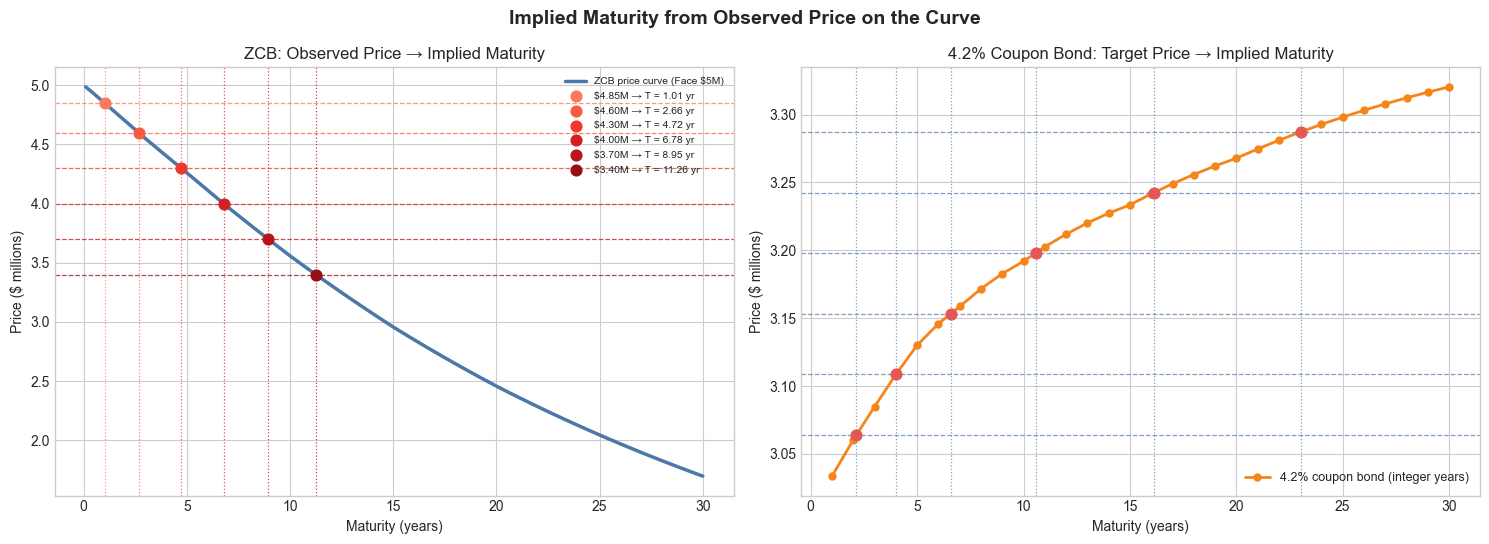

In [10]:
from scipy.optimize import brentq

# -----------------------------------------------------------------------
# 4.1  Zero-Coupon Bond — continuous inversion via brentq
# -----------------------------------------------------------------------

def zcb_implied_maturity(face: float, price: float) -> float:
    """Return T such that face × DF(0, T) == price."""
    return float(brentq(lambda t: zcb_price(face, t) - price, 0.01, 30.0))


zcb_face_ex     = 5_000_000
zcb_test_prices = np.array([4_850_000, 4_600_000, 4_300_000, 4_000_000, 3_700_000, 3_400_000])

zcb_rows = []
for p in zcb_test_prices:
    T_impl = zcb_implied_maturity(zcb_face_ex, p)
    zcb_rows.append(
        {
            "observed_price":         p,
            "implied_DF":             p / zcb_face_ex,
            "implied_maturity_years": T_impl,
            "zero_rate_at_T (%)":     100.0 * zero_rate(T_impl),
            "check_price":            zcb_price(zcb_face_ex, T_impl),
        }
    )

zcb_impl_df = pd.DataFrame(zcb_rows)
print("Zero-Coupon Bond (Face = $5 000 000) — Implied Maturity from Observed Price")
display(zcb_impl_df)

# -----------------------------------------------------------------------
# 4.2  Fixed-Coupon Bond — discrete grid search + linear interpolation
# -----------------------------------------------------------------------

bond_face_ex    = 3_000_000
bond_coupon_ex  = 0.042
bond_mat_grid   = np.arange(1, 31, dtype=float)
bond_price_grid = np.array([fixed_bond_price(bond_face_ex, bond_coupon_ex, int(m)) for m in bond_mat_grid])


def coupon_bond_implied_maturity(face: float, coupon: float, target_price: float) -> float | None:
    """
    Linearly interpolate between adjacent integer maturities to find T
    where fixed_bond_price(face, coupon, T) ≈ target_price.
    Returns None if target_price is outside the achievable range.
    """
    prices = np.array([fixed_bond_price(face, coupon, int(m)) for m in np.arange(1, 31)])
    mats   = np.arange(1, 31, dtype=float)
    diffs  = prices - target_price
    for i in range(len(diffs) - 1):
        if diffs[i] * diffs[i + 1] <= 0:
            t1, t2 = mats[i], mats[i + 1]
            p1, p2 = prices[i], prices[i + 1]
            return float(t1 + (target_price - p1) / (p2 - p1) * (t2 - t1))
    return None


cb_min, cb_max  = bond_price_grid.min(), bond_price_grid.max()
cb_test_prices  = np.linspace(cb_min * 1.01, cb_max * 0.99, 6)

cb_rows = []
for p in cb_test_prices:
    T_impl = coupon_bond_implied_maturity(bond_face_ex, bond_coupon_ex, p)
    cb_rows.append(
        {
            "target_price":           p,
            "implied_maturity_years": T_impl,
        }
    )

cb_impl_df = pd.DataFrame(cb_rows)
print(f"\n4.2% Coupon Bond ($3M face) — Achievable price range: ${cb_min:,.0f} – ${cb_max:,.0f}")
print("Implied Maturity from Target Price")
display(cb_impl_df)

# -----------------------------------------------------------------------
# Charts
# -----------------------------------------------------------------------

T_fine    = np.linspace(0.1, 30.0, 600)
zcb_curve = np.array([zcb_price(zcb_face_ex, t) for t in T_fine]) / 1e6

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left — ZCB
axes[0].plot(T_fine, zcb_curve, linewidth=2.5, color="#4C78A8", label="ZCB price curve (Face $5M)")
cmap = plt.cm.Reds(np.linspace(0.45, 0.90, len(zcb_rows)))
for row, col in zip(zcb_rows, cmap):
    p_m = row["observed_price"] / 1e6
    T_m = row["implied_maturity_years"]
    axes[0].axhline(p_m, color=col, linestyle="--", linewidth=0.9, alpha=0.75)
    axes[0].axvline(T_m, color=col, linestyle=":",  linewidth=0.9, alpha=0.75)
    axes[0].scatter([T_m], [p_m], color=col, zorder=5, s=60,
                    label=f"${p_m:.2f}M → T = {T_m:.2f} yr")
axes[0].set_title("ZCB: Observed Price → Implied Maturity")
axes[0].set_xlabel("Maturity (years)")
axes[0].set_ylabel("Price ($ millions)")
axes[0].legend(fontsize=7.5, loc="upper right")

# Right — Coupon bond (integer-year dots connected by a line)
axes[1].plot(bond_mat_grid, bond_price_grid / 1e6, marker="o", markersize=5,
             linewidth=2, color="#F58518", label="4.2% coupon bond (integer years)")
for row in cb_rows:
    if row["implied_maturity_years"] is not None:
        p_m = row["target_price"] / 1e6
        T_m = row["implied_maturity_years"]
        axes[1].axhline(p_m, color="#4C78A8", linestyle="--", linewidth=0.9, alpha=0.70)
        axes[1].axvline(T_m, color="#4C78A8", linestyle=":",  linewidth=0.9, alpha=0.70)
        axes[1].scatter([T_m], [p_m], color="#E45756", zorder=5, s=60)
axes[1].set_title("4.2% Coupon Bond: Target Price → Implied Maturity")
axes[1].set_xlabel("Maturity (years)")
axes[1].set_ylabel("Price ($ millions)")
axes[1].legend(fontsize=9)

fig.suptitle("Implied Maturity from Observed Price on the Curve", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()


### How to read the implied-maturity charts

Both charts use the same visual language: a **dashed horizontal line** marks the target price; a **dotted vertical line** marks the implied maturity; the **coloured dot** is the intersection on the price-vs-maturity curve.

#### Left — Zero-Coupon Bond

- x-axis: maturity in years (0 to 30)
- y-axis: ZCB price in millions
- The curve is **strictly decreasing**: every additional year of waiting requires heavier discounting, so the price you would pay today is lower.
- Each dashed horizontal line is an observed price. Trace it rightward until it meets the curve, then drop straight down to the x-axis — that x value is the implied maturity.
- The `check_price` column in the table confirms the inversion is exact: `zcb_price(face, T_implied)` should exactly reproduce the observed price.

#### Right — Fixed-Coupon Bond (4.2%)

- The orange dots are the fair prices at **integer maturities** (1, 2, 3, … 30 years) connected by a line.
- Because the coupon rate (4.2%) is **higher than the prevailing zero rates** (2.8%–3.6%), this is a **premium bond** — its price is always **above the $3M face value**, and the price generally rises with maturity as more above-market coupons are accumulated.
- Red dots mark the interpolated maturity for each target price. The implied maturity is fractional because the target price falls between two integer-year prices.
- If the target price falls **outside** the achievable range (below the 1-year price or above the 30-year price), no solution exists — the column will be blank.

#### Key differences between the two assets

| Feature | ZCB | Coupon Bond |
|---|---|---|
| Price-maturity relationship | Strictly decreasing | Monotonic (direction depends on coupon vs yield) |
| Inversion method | Continuous root-finding (`brentq`) | Discrete grid search + linear interpolation |
| Accuracy | Exact | Approximate (interpolation error ≈ small) |
| Uniqueness | Always unique | Unique only if coupon ≠ par rate |

**Practical takeaway:** In real markets, this inversion is done constantly when *stripping* government bonds into zero-coupon instruments or when *bootstrapping* a discount curve from a set of observed bond prices. The logic here is identical — just applied to real market data instead of the synthetic curve.


## Main Takeaways

### Core ideas to remember

1. **Discount factors are the foundation.** Every interest rate asset — no matter how complex — is ultimately priced by discounting its future cash flows. Once you understand discount factors, everything else follows.

2. **The yield curve is a pricing engine.** Given a curve, you can price bonds, FRAs, swaps, and many other instruments using the same discounting framework. The curve is the single most important input.

3. **Forward rates are derived, not observed.** They are implied by the no-arbitrage consistency of the curve. These "implied" rates drive FRA payoffs and swap floating leg valuations.

4. **Bonds and swaps react oppositely to rate changes.** When rates rise, bond prices fall but payer swap NPVs rise. This makes swaps the natural hedge for fixed-rate bond portfolios.

5. **Sensitivity tells you your risk.** A parallel shock analysis shows how much your position changes for every 1 bp of rate movement. In practice this is formalised as DV01 (dollar value of a basis point) — the cornerstone of fixed-income risk management.

---

### Beginner checklist — can you answer these?

- [ ] If the 3-year zero rate rises by 50 bp, what happens to the price of a 3-year zero-coupon bond?
- [ ] Why does a fixed-coupon bond with a coupon *higher* than the market rate trade above its face value?
- [ ] A company wants to fix its floating-rate borrowing cost for 5 years. Should it enter a payer or receiver swap?
- [ ] If the implied forward rate for a future period is 3.8% and a FRA is struck at 3.6%, who benefits: the FRA buyer or seller?
- [ ] What does a Macaulay duration of 6.2 years tell you about rate sensitivity?

---

### Concepts to explore next

- **Multi-curve framework**: real trading desks use separate curves for discounting (OIS/SOFR) and forward rate projection (LIBOR or SOFR term rates)
- **Day-count and business-day conventions**: actual bond and swap contracts use specific calendars and accrual rules that affect cash flows
- **Caps, floors, and swaptions**: options on interest rates — the next layer of complexity once you are comfortable with linear products
- **Historical and parametric VaR for rate portfolios**: turning sensitivity analysis into a full risk measure
- **Yield curve fitting**: how desks bootstrap or parametrically fit curves (Nelson-Siegel, splines) from observed market prices
